In [884]:
import pandas as pd
import numpy as np
import scipy.io as scio
import mat73
import os
import sys
from tqdm import tqdm
from collections import defaultdict
import openpyxl 
import dill
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import permutation_test_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import RobustScaler
from sklearn.inspection import permutation_importance
import importlib
import helper_function as hf
importlib.reload(hf)
import plotting_functions as pf
importlib.reload(pf)

<module 'plotting_functions' from '/lisc/home/user/madhusudhanan/python_scripts_oncluster/plotting_functions.py'>

In [885]:
#IMPORT data from matlab files
dd= pd.read_csv("/lisc/data/scratch/neurobiology/zimmer/jalaja/imaging/newline/cleaned/for_BundleNet/deltaFoF_alldataset.csv", delimiter=',',parse_dates=True)
dd.columns=dd.columns.str.strip("''")
dd

,AIBL,AIBR,AIZL,ALA,ALNL,ALNR,AQR,AS10,ASKL,ASKR,...,URYVR,VA01,VA11,VA12,VB01,VB02,VD13,target,state,group
0,0.387170,0.097740,0.312340,0.145770,NaN,0.95588,-0.11433,0.003151,1.35830,0.554600,...,0.073543,0.12440,NaN,NaN,0.62955,0.098488,0.015532,2,1,1
1,0.418530,0.069665,0.267290,0.128760,NaN,0.92111,-0.13575,-0.015684,1.27280,0.570670,...,0.046784,0.12474,NaN,NaN,0.61028,0.084541,0.013973,2,1,1
2,0.448780,0.051929,0.239980,0.105750,NaN,0.87986,-0.14115,-0.037594,1.16260,0.580160,...,0.033031,0.12504,NaN,NaN,0.57180,0.079309,-0.002591,2,1,1
3,0.477770,0.045791,0.232590,0.076009,NaN,0.83133,-0.12856,-0.062951,1.02460,0.582280,...,0.033870,0.12532,NaN,NaN,0.51179,0.083855,-0.035988,2,1,1
4,0.475250,0.053608,0.209490,0.073328,NaN,0.85503,-0.13928,-0.052906,0.95813,0.536360,...,0.039577,0.13207,NaN,NaN,0.51291,0.082970,-0.007096,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85045,-0.100090,-0.123270,-0.091191,-0.339340,-0.35703,-0.48824,-0.22803,NaN,-0.19723,-0.132620,...,-0.126310,NaN,-0.052055,0.103360,-0.18571,-0.098487,0.198120,2,1,9
85046,-0.086111,-0.106290,-0.089964,-0.339710,-0.34738,-0.48779,-0.20283,NaN,-0.19967,-0.128080,...,-0.127810,NaN,-0.058894,0.097431,-0.19207,-0.100030,0.206260,2,1,9
85047,-0.089498,-0.134590,-0.097088,-0.355450,-0.33665,-0.49817,-0.20000,NaN,-0.19820,-0.117480,...,-0.114520,NaN,-0.066565,0.095080,-0.20473,-0.103260,0.214000,2,1,9
85048,-0.090512,-0.149300,-0.092970,-0.346930,-0.33888,-0.49830,-0.20349,NaN,-0.20218,-0.108090,...,-0.120090,NaN,-0.053817,0.091680,-0.20745,-0.111210,0.203250,2,1,9


In [886]:
dd.columns

Index(['AIBL', 'AIBR', 'AIZL', 'ALA', 'ALNL', 'ALNR', 'AQR', 'AS10', 'ASKL',
       'ASKR', 'AUAL', 'AUAR', 'AVAL', 'AVAR', 'AVEL', 'AVER', 'BAGL', 'BAGR',
       'DA01', 'DA07', 'DA09', 'DB01', 'DB02', 'DB07', 'DVA', 'IL2L', 'IL2R',
       'PQR', 'PVNL', 'PVNR', 'PVPL', 'RIBL', 'RIBR', 'RID', 'RIML', 'RIMR',
       'RIS', 'RIVL', 'RIVR', 'RMGL', 'RMGR', 'SIADL', 'SIADR', 'SMBDL',
       'SMBDR', 'SMBVL', 'SMDDL', 'SMDDR', 'SMDVL', 'SMDVR', 'URXL', 'URXR',
       'URYDL', 'URYDR', 'URYVL', 'URYVR', 'VA01', 'VA11', 'VA12', 'VB01',
       'VB02', 'VD13', 'target', 'state', 'group'],
      dtype='object')

In [ ]:
#Normalize scaling beaseline and stimulus period separately because of special request
fps = 5
# simple mean imputation from sklearn
# imp=SimpleImputer(strategy='mean')
X=dd.drop({'target','state','group'},axis=1)
#Normalize scaling
scaled_datasets_X_baseline = []
scaled_datasets_X_stimulus = []
for n in range(0, 9):
    #robust_scaler=StandardScaler()
    robust_scaler=RobustScaler(with_centering=False, with_scaling=True, quantile_range=(5, 95))
    scaled_data_X_baseline = robust_scaler.fit_transform(X.loc[n*9450:(n*9450)+(390*fps)-1,:])
    scaled_data_X_stimulus = robust_scaler.fit_transform(X.loc[(n*9450)+(390*fps):((n+1)*9450)-1,:])
    
    scaled_datasets_X_baseline.append(scaled_data_X_baseline)
    scaled_datasets_X_stimulus.append(scaled_data_X_stimulus)

# Concatenate scaled datasets from each group
scaled_X_within_group_baseline = np.concatenate(scaled_datasets_X_baseline)
scaled_X_within_group_stimulus = np.concatenate(scaled_datasets_X_stimulus)

# Scale across all groups
scaled_X_across_groups_baseline = robust_scaler.fit_transform(scaled_X_within_group_baseline)
scaled_X_baseline =pd.DataFrame(data=scaled_X_across_groups_baseline,columns=X.columns)

scaled_X_across_groups_stimulus = robust_scaler.fit_transform(scaled_X_within_group_stimulus)
scaled_X_stimulus =pd.DataFrame(data=scaled_X_across_groups_stimulus,columns=X.columns)

normalized=[]
for n in range(0, 9):
   
    normalized.append(scaled_X_baseline.loc[n*390*fps:((n+1)*390*fps)-1,:])
    normalized.append(scaled_X_stimulus.loc[n*1500*fps:((n+1)*1500*fps)-1,:])
    
# Combine all normalized data
normalized = pd.concat(normalized, axis=0).reset_index(drop=True)

# Add back the target, state, and group columns
normalized_data = normalized.copy()
normalized_data['target'] = dd['target'].values
normalized_data['state'] = dd['state'].values
normalized_data['group'] = dd['group'].values

# Ensure column names are clean
normalized_data.columns = normalized_data.columns.str.strip("''")

In [ ]:
#REPLACE MISSING VALUES
imp=IterativeImputer(random_state=0)
# imp=SimpleImputer(strategy='mean')
dk=imp.fit_transform(normalized_data.drop({'target','state','group'}, axis=1))
df = pd.DataFrame(data=np.c_[dk, dd['target'],dd['state'],dd['group']],columns=dd.columns)

In [839]:
#sometimes the server connection is poor that it get stuck at this step and can not proceed :( In that case, I skip and use the saved version of the output.
df=pd.read_csv("/lisc/data/scratch/neurobiology/zimmer/jalaja/imaging/newline/cleaned/for_BundleNet/deltaFoF_alldataset_normalized_imputed.csv",index_col=0)

In [1068]:
df

,AIBL,AIBR,AIZL,ALA,ALNL,ALNR,AQR,AS10,ASKL,ASKR,...,URYVR,VA01,VA11,VA12,VB01,VB02,VD13,target,state,group
0,0.251238,0.207637,1.501193,0.825515,1.884658,2.513866,-0.464311,0.015814,2.163814,0.913401,...,0.540133,0.509066,0.336539,-0.137205,0.613915,0.474432,0.014760,2.0,1.0,1.0
1,0.271588,0.147995,1.284670,0.729185,1.891591,2.422424,-0.551300,-0.078703,2.027610,0.939867,...,0.343603,0.510457,0.306629,-0.175963,0.595124,0.407247,0.013278,2.0,1.0,1.0
2,0.291217,0.110317,1.153410,0.598876,1.918554,2.313941,-0.573230,-0.188648,1.852058,0.955497,...,0.242595,0.511685,0.223159,-0.200826,0.557599,0.382044,-0.002462,2.0,1.0,1.0
3,0.310029,0.097278,1.117892,0.430449,1.968030,2.186312,-0.522101,-0.315890,1.632220,0.958989,...,0.248757,0.512830,0.079560,-0.210110,0.499080,0.403943,-0.034199,2.0,1.0,1.0
4,0.308394,0.113884,1.006867,0.415266,1.915258,2.248641,-0.565636,-0.265484,1.526331,0.883360,...,0.290671,0.540452,0.142972,-0.190987,0.500172,0.399680,-0.006743,2.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85045,-0.443202,-0.332772,-0.300448,-0.513417,-0.599186,-0.587684,-0.160291,-0.038771,-0.553995,-0.348767,...,-0.705256,-0.503544,-0.214125,0.339156,-0.537296,-0.568791,0.386257,2.0,1.0,9.0
85046,-0.381303,-0.286934,-0.296405,-0.513976,-0.582990,-0.587142,-0.142577,-0.034647,-0.560848,-0.336827,...,-0.713632,-0.508977,-0.242257,0.319701,-0.555697,-0.577702,0.402127,2.0,1.0,9.0
85047,-0.396300,-0.363331,-0.319876,-0.537791,-0.564983,-0.599636,-0.140588,0.050027,-0.556719,-0.308951,...,-0.639426,-0.527050,-0.273811,0.311986,-0.592325,-0.596356,0.417217,2.0,1.0,9.0
85048,-0.400790,-0.403041,-0.306309,-0.524900,-0.568725,-0.599793,-0.143041,0.067907,-0.567899,-0.284257,...,-0.670527,-0.528432,-0.221373,0.300830,-0.600195,-0.642270,0.396259,2.0,1.0,9.0


In [1074]:
# create triggered traces
    # Parameters
interval_start = 450 # start at 390 seconds
interval_step = 90  # interval of 90 seconds
slice_duration = 60  # slice the prestimulus 60 seconds
stimulus_period=30
fps = 5  # frames per second

# Create the new sliced DataFrame
sliced_df , triggered_df= hf.create_sliced_dataframe(df, interval_start, interval_step, slice_duration,stimulus_period, fps)
print(triggered_df)

           AIBL      AIBR      AIZL       ALA      ALNL      ALNR       AQR  \
1950  -0.120777 -0.259240  0.201684  0.108614 -0.098040 -0.095842 -0.169929   
1951  -0.140790 -0.226471  0.313163  0.150455 -0.042338 -0.108601 -0.168322   
1952  -0.170853 -0.266413  0.511999  0.174565  0.017799 -0.085943 -0.157742   
1953  -0.186939 -0.254684  0.443138  0.158520 -0.153994 -0.090244 -0.151592   
1954  -0.193594 -0.252521  0.381341  0.109499 -0.265305 -0.096667 -0.149256   
...         ...       ...       ...       ...       ...       ...       ...   
84745 -0.254121 -0.169739 -0.434704 -0.548215 -0.498491 -0.624480  0.121967   
84746 -0.249887 -0.168864 -0.463730 -0.547807 -0.499934 -0.616608  0.113651   
84747 -0.336801 -0.252115 -0.420306 -0.538214 -0.497400 -0.610349  0.123647   
84748 -0.378008 -0.252572 -0.428872 -0.545961 -0.482363 -0.627140  0.111901   
84749 -0.392886 -0.218646 -0.458722 -0.558942 -0.462140 -0.650600  0.092219   

           AS10      ASKL      ASKR  ...     URYVR 

In [1075]:
# Drop rows where 'target' is 2
triggered_df_forPLS = triggered_df[triggered_df['target'] != 2]

In [1077]:
df_pls=pd.DataFrame(data=sliced_df)
# Drop rows where 'target_vector' is 2
sliced_df_forPLS = df_pls[df_pls['target'] != 2]
pls_X=triggered_df_forPLS.drop({'target','state','group'},axis=1)
pls_x=sliced_df_forPLS.drop({'target','state','group'},axis=1)
motor_neurons={'DB01','DB02','DB07','VB01','VB02','AS10','DA01','DA07','DA09','VA01','VA11','VA12','VD13','target','state','group'}
exclude={'ASKR','BAGL','URXR','VB01','SMBDL','SIADL','AVAL','AIBL','SMDVL','RIML','RIMR','ALNL','SMDVR','DB02','RIVL','DA09','URYVR','AVAR','AQR','VA01','URYDL','AUAL','AVEL','DA07','IL2R','target','state','group'}
pls_x_nomotor=df_pls.drop(exclude,axis=1)
y=sliced_df_forPLS['target']
groups=sliced_df_forPLS['group']

In [1078]:
sliced_df_forPLS

,AIBL,AIBR,AIZL,ALA,ALNL,ALNR,AQR,AS10,ASKL,ASKR,...,URYVR,VA01,VA11,VA12,VB01,VB02,VD13,target,state,group
1950,-0.120777,-0.259240,0.201684,0.108614,-0.098040,-0.095842,-0.169929,0.050057,-0.439269,-0.225630,...,0.085433,0.255499,0.124649,-0.079859,0.033571,0.104174,0.148269,1.0,1.0,1.0
1951,-0.140790,-0.226471,0.313163,0.150455,-0.042338,-0.108601,-0.168322,-0.003534,-0.434617,-0.196835,...,0.091805,0.276585,0.055665,-0.085252,0.023907,0.034036,0.143029,1.0,1.0,1.0
1952,-0.170853,-0.266413,0.511999,0.174565,0.017799,-0.085943,-0.157742,-0.018358,-0.432899,-0.172524,...,0.171086,0.319356,-0.011102,-0.061161,0.042978,0.120342,0.137717,1.0,1.0,1.0
1953,-0.186939,-0.254684,0.443138,0.158520,-0.153994,-0.090244,-0.151592,0.071262,-0.410500,-0.126472,...,0.080038,0.265000,0.090665,-0.035786,0.046854,0.189628,0.121635,1.0,1.0,1.0
1954,-0.193594,-0.252521,0.381341,0.109499,-0.265305,-0.096667,-0.149256,0.089051,-0.389101,-0.101405,...,-0.000766,0.209072,0.135144,-0.040554,0.045720,0.233686,0.104032,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84595,-0.234141,-0.381661,-0.235542,-0.453336,-0.500286,-0.624528,-0.145740,0.006797,-0.152407,0.012582,...,-0.515260,-0.508193,-0.052483,0.245970,-0.457241,-0.542028,0.525986,0.0,1.0,9.0
84596,-0.234106,-0.378502,-0.210888,-0.451097,-0.490401,-0.617968,-0.144320,-0.018514,-0.187057,0.013999,...,-0.452356,-0.526431,-0.090027,0.220336,-0.482094,-0.579030,0.517076,0.0,1.0,9.0
84597,-0.274135,-0.376856,-0.293723,-0.469389,-0.511447,-0.642391,-0.151610,0.055495,-0.234816,-0.080215,...,-0.308596,-0.431543,-0.178429,0.206371,-0.516118,-0.622460,0.563243,0.0,1.0,9.0
84598,-0.306026,-0.349077,-0.288672,-0.471855,-0.522506,-0.642223,-0.155350,0.081089,-0.310577,-0.125195,...,-0.415181,-0.412126,-0.149959,0.203365,-0.515077,-0.609928,0.556088,0.0,1.0,9.0


In [1079]:
from sklearn.cross_decomposition import PLSCanonical
from sklearn.cross_decomposition import PLSRegression

pls = PLSRegression(n_components=5)
#pls.fit(pls_x_nomotor, y)
pls.fit(pls_x,y)
#opls= PLSCanonical(n_components=1)
#opls.fit(pls_x,y)
# pls.fit(pc,y) 

PLSRegression(n_components=5)

In [1080]:
pls.score(pls_x,y)

0.2661188993256891

In [1085]:
# Define the columns to smooth
columns_to_smooth = PLS1_df.columns

# Apply the smoothing function, here simple moving average
PLS1_smooth = hf.smooth_data(PLS1_df, columns_to_smooth, window=10)
PLS2_smooth = hf.smooth_data(PLS2_df, columns_to_smooth, window=10)
PLS3_smooth = hf.smooth_data(PLS3_df, columns_to_smooth, window=10)


In [1086]:
df_pls_x=sliced_df_forPLS.drop({'state'},axis=1)
df_pls_X=triggered_df_forPLS.drop({'state'},axis=1)

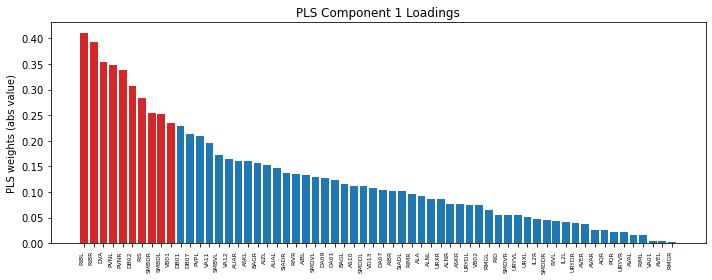

In [1087]:
# Plot the first component, highlight top 10 neurons
df_loadings = pf.plot_pls_loadings(pls, pls_x, component=0, top_n=10)

In [1088]:
np.sum(abs(pls.x_loadings_[:,0]))

8.025054441987557

In [393]:
def plot_permutation_importance(clf, X, y, ax):
    result = permutation_importance(clf, X, y, n_repeats=10, random_state=42, n_jobs=2)
    print(result)
    perm_sorted_idx = result.importances_mean.argsort()

    ax.boxplot(
        result.importances[perm_sorted_idx].T,
        vert=False,
        labels=X.columns[perm_sorted_idx],
    )
    ax.axvline(x=0, color="k", linestyle="--")
    return ax

In [1096]:
result

{'importances_mean': array([0.14196011, 0.04836182, 0.04064672]),
 'importances_std': array([0.00198061, 0.001803  , 0.00154415]),
 'importances': array([[0.14039886, 0.14108262, 0.14404558, 0.14071225, 0.14031339,
         0.14042735, 0.14205128, 0.1439886 , 0.14623932, 0.14034188],
        [0.04615385, 0.04957265, 0.04880342, 0.04766382, 0.0502849 ,
         0.0454416 , 0.05173789, 0.04843305, 0.04851852, 0.04700855],
        [0.03854701, 0.03903134, 0.04011396, 0.04159544, 0.04025641,
         0.04307692, 0.04230769, 0.04262108, 0.03923077, 0.03968661]])}

{'importances_mean': array([0.1418547 , 0.05200855, 0.03881197, 0.00568376, 0.02150997]), 'importances_std': array([0.00208268, 0.00132307, 0.00140234, 0.00089544, 0.00089985]), 'importances': array([[0.14096866, 0.13894587, 0.14364672, 0.14091168, 0.13974359,
        0.14045584, 0.14165242, 0.14529915, 0.14527066, 0.14165242],
       [0.05165242, 0.05387464, 0.0534188 , 0.05156695, 0.05356125,
        0.05019943, 0.0519943 , 0.05270655, 0.04974359, 0.05136752],
       [0.0377208 , 0.03837607, 0.03863248, 0.03968661, 0.03598291,
        0.04116809, 0.03988604, 0.0391453 , 0.03760684, 0.03991453],
       [0.00569801, 0.00487179, 0.00698006, 0.00518519, 0.00615385,
        0.00641026, 0.00441595, 0.00712251, 0.00518519, 0.00481481],
       [0.02276353, 0.0217094 , 0.02133903, 0.02202279, 0.02185185,
        0.01968661, 0.02165242, 0.02054131, 0.02267806, 0.0208547 ]])}


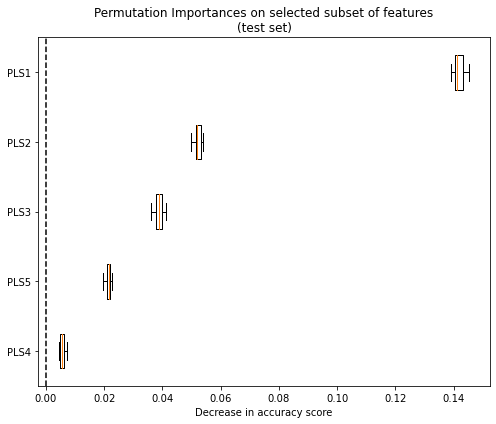

In [1089]:
pls_x_transformed=pd.DataFrame(data=np.c_[pls.transform(pls_x),sliced_df_forPLS['target'],sliced_df_forPLS['group']],columns=['PLS1','PLS2','PLS3','PLS4','PLS5','target','group'])
lda = LinearDiscriminantAnalysis().fit(pls_x_transformed.drop({'target','group'},axis=1), y)
fig, ax = plt.subplots(figsize=(7, 6))
plot_permutation_importance(lda, pls_x_transformed.drop({'target','group'},axis=1) , y, ax)
ax.set_title("Permutation Importances on selected subset of features\n(test set)")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()
plt.show()

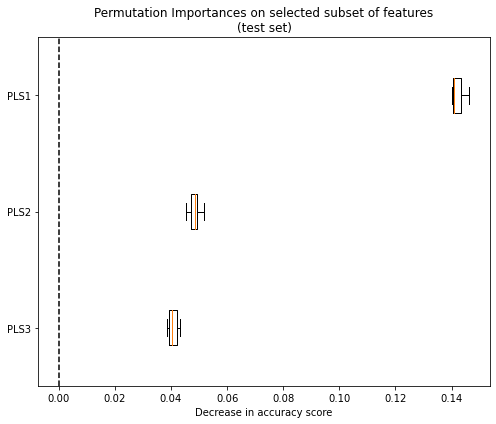

In [1095]:
#Let's restrict to first 3 PLS dimensions.
pls = PLSRegression(n_components=3)
pls.fit(pls_x,y)
pls_x_transformed=pd.DataFrame(data=np.c_[pls.transform(pls_x),sliced_df_forPLS['target'],sliced_df_forPLS['group']],columns=['PLS1','PLS2','PLS3','target','group'])
X=pls_x_transformed.drop({'target','group'},axis=1)
lda = LinearDiscriminantAnalysis().fit(X, y)
result = permutation_importance(lda, X, y, n_repeats=10, random_state=42, n_jobs=2)
fig, ax = plt.subplots(figsize=(7, 6))
pf.plot_permutation_importance(result,X, ax)
ax.set_title("Permutation Importances on selected subset of features\n(test set)")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()
plt.show()

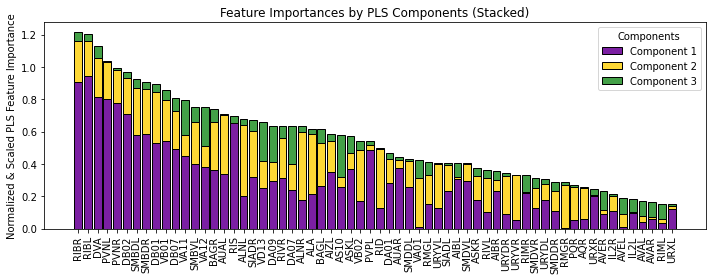

In [1093]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming `pls`, `result`, and `pls_x` are defined in your context
# result = permutation_importance(lda, pls_x_transformed.drop({'target','group'},axis=1), y, n_repeats=10, random_state=42, n_jobs=2)
# Extract permutation importance means for the first 3 components
importance_means = [18.5,11.1,4.2]  # Mean importance for each component

# Normalize loadings for each component and compute scaled loadings
stacked_loadings = []
for i in range(3):
    # Normalize loadings within the component
    normalized_loadings = pls.x_loadings_[:, i] / np.sum(np.abs(pls.x_loadings_[:, i]))
    # Scale by the corresponding importance mean
    scaled_loadings = np.abs(importance_means[i] * normalized_loadings)
    stacked_loadings.append(scaled_loadings)

# Combine the normalized and scaled loadings into a DataFrame
stacked_loadings_df = pd.DataFrame(
    np.array(stacked_loadings).T,  # Transpose so rows are neurons, columns are components
    columns=[f"Component {i+1}" for i in range(3)]
)
stacked_loadings_df["neurons"] = pls_x.columns  # Add neuron identifiers
stacked_loadings_df["total_loading"] = stacked_loadings_df.iloc[:, :-1].sum(axis=1)  # Total contribution

# Sort by total absolute contribution
stacked_loadings_df = stacked_loadings_df.sort_values("total_loading", ascending=False)

# Prepare for plotting
num_bars = len(stacked_loadings_df)
x_pos = np.linspace(0, num_bars - 1, num_bars)  # Ensure equal spacing
components = [f"Component {i+1}" for i in range(3)]

# Define colors (Purple, Yellow, Green)
colors = ['#7B1FA2', '#FDD835', '#43A047']

# Create compact figure
fig, ax = plt.subplots(figsize=(10, 4))  
bars = []

for idx, component in enumerate(components):
    bars.append(
        ax.bar(
            x_pos, 
            stacked_loadings_df[component], 
            bottom=stacked_loadings_df[components[:idx]].sum(axis=1) if idx > 0 else 0,
            label=component, 
            color=colors[idx],
            edgecolor='black'
        )
    )

# Customize plot
ax.set_xticks(x_pos)
ax.set_xticklabels(stacked_loadings_df["neurons"], fontsize=10, rotation=90)
ax.set_ylabel('Normalized & Scaled PLS Feature Importance', fontsize=10)
ax.set_title('Feature Importances by PLS Components (Stacked)', fontsize=12)
ax.legend(title='Components', loc='upper right', fontsize=10)
plt.tight_layout()  # Optimize spacing
plt.rcParams['svg.fonttype'] = 'none'
# Save as SVG
# plt.savefig("pls_feature_importance.svg", format="svg", bbox_inches="tight")

# Show plot
plt.show()


In [491]:
total_contribution_per_component.sum()

0.25036182336182344

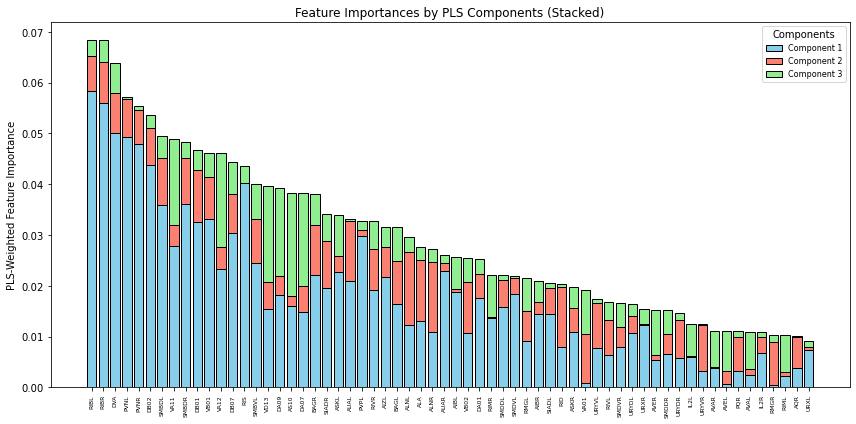

In [1100]:
result = permutation_importance(lda, pls_x_transformed.drop({'target','group'},axis=1), y, n_repeats=10, random_state=42, n_jobs=2)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming `pls_x`, `result`, `pls` are defined as in your context

# Map permutation importance to PLS loadings for all components
importance_means = result.importances_mean[:3]  # Mean importance for each component
stacked_loadings = []

for i in range(3):
    stacked_loadings.append(np.abs(importance_means[i] * pls.x_loadings_[:, i]))

# Combine the loadings into a DataFrame for easier manipulation
stacked_loadings_df = pd.DataFrame(
    np.array(stacked_loadings).T,  # Transpose so rows are neurons, columns are components
    columns=[f"Component {i+1}" for i in range(3)]
)
stacked_loadings_df["neurons"] = pls_x.columns
stacked_loadings_df["total_loading"] = stacked_loadings_df.iloc[:, :-1].sum(axis=1)

# Sort by total absolute contribution
stacked_loadings_df = stacked_loadings_df.sort_values("total_loading", ascending=False)

# Prepare for plotting
x_pos = np.arange(len(stacked_loadings_df))
components = [f"Component {i+1}" for i in range(3)]

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6))
bars = []
colors = ['skyblue', 'salmon', 'lightgreen', 'gold', 'orchid']  # Extend for more components if needed

for idx, component in enumerate(components):
    bars.append(
        ax.bar(
            x_pos, 
            stacked_loadings_df[component], 
            bottom=stacked_loadings_df[components[:idx]].sum(axis=1) if idx > 0 else 0,
            label=component, 
            color=colors[idx % len(colors)],
            edgecolor='black'
        )
    )

# Customize plot
ax.set_xticks(x_pos)
ax.set_xticklabels(
    stacked_loadings_df["neurons"], 
    fontsize=6, rotation=90, ha='center', va='top'
)
ax.set_ylabel('PLS-Weighted Feature Importance')
ax.set_title('Feature Importances by PLS Components (Stacked)', fontsize=12)
ax.legend(title='Components', loc='upper right', fontsize=8)
plt.tight_layout()

# Show plot
plt.show()



In [303]:
importance_means

array([0.12554416, 0.06003989, 0.05775214])

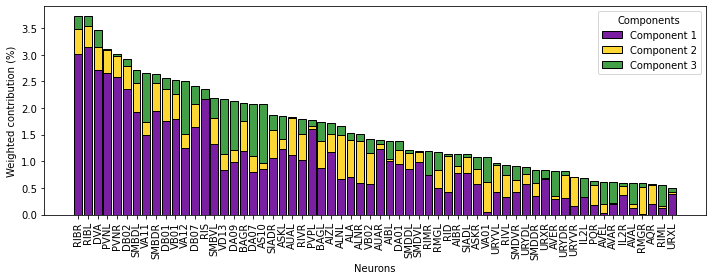

In [1099]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming `pls`, `result`, and `pls_x` are defined in your context

# Extract permutation importance means for the first 3 components
importance_means = result.importances_mean[:3]  # Mean importance for each component

# Compute absolute contributions
stacked_loadings = []
for i in range(3):
    # Normalize loadings within the component
    normalized_loadings = pls.x_loadings_[:, i] / np.sum(np.abs(pls.x_loadings_[:, i]))
    # Scale by importance mean
    scaled_loadings = np.abs(importance_means[i] * normalized_loadings)
    stacked_loadings.append(scaled_loadings)

# Convert to NumPy array
stacked_loadings = np.array(stacked_loadings).T  # Shape: (neurons, components)

# Compute total contribution per component
total_contribution_per_component = np.sum(stacked_loadings, axis=0, keepdims=True)  # (1, components)

# Normalize so that each component's total contribution across all neurons sums to 100%
percentage_contributions = (stacked_loadings / total_contribution_per_component.sum()) * 100  # Convert to %

# Create DataFrame
stacked_loadings_df = pd.DataFrame(
    percentage_contributions, 
    columns=[f"Component {i+1}" for i in range(3)]
)
stacked_loadings_df["neurons"] = pls_x.columns  # Add neuron identifiers

# Calculate total contribution for each neuron across all components
stacked_loadings_df["total_loading"] = stacked_loadings_df.iloc[:, :-1].sum(axis=1)

# Sort by total contribution across all components (descending)
stacked_loadings_df = stacked_loadings_df.sort_values("total_loading", ascending=False)

# Prepare for plotting
num_bars = len(stacked_loadings_df)
x_pos = np.linspace(0, num_bars - 1, num_bars)  # Ensure equal spacing
components = [f"Component {i+1}" for i in range(3)]

# Define colors (Purple, Yellow, Green)
colors = ['#7B1FA2', '#FDD835', '#43A047']

# Create compact figure
fig, ax = plt.subplots(figsize=(10, 4))
bars = []

for idx, component in enumerate(components):
    bars.append(
        ax.bar(
            x_pos, 
            stacked_loadings_df[component], 
            bottom=stacked_loadings_df[components[:idx]].sum(axis=1) if idx > 0 else 0,
            label=component, 
            color=colors[idx],
            edgecolor='black'
        )
    )

# Customize plot
ax.set_xticks(x_pos)
ax.set_xticklabels(stacked_loadings_df["neurons"], fontsize=10, rotation=90)
ax.set_ylabel('Weighted contribution (%)', fontsize=10)
ax.set_xlabel('Neurons', fontsize=10)
# ax.set_title('Neuron Contribution to PLS Components (Stacked, Total Across Neurons = 100%)', fontsize=12)
ax.legend(title='Components', loc='upper right', fontsize=10)

# # Show percentage labels on bars
# for bar_group in bars:
#     for bar in bar_group:
#         height = bar.get_height()
#         if height > 2:  # Only show labels for significant contributions
#             ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2, 
#                     f"{height:.1f}%", ha='center', va='center', fontsize=8, color="black")

plt.tight_layout()  # Optimize spacing

# Save as SVG
# plt.savefig("pls_neuron_contribution_sorted_total_100percent.svg", format="svg", bbox_inches="tight")

# Show plot
plt.show()


In [ ]:
len(pls_df_for_lda)/total_trials

In [ ]:
pls_x_transformed=pd.DataFrame(data=np.c_[pls.transform(pls_x),sliced_df_forPLS['target'],sliced_df_forPLS['group']],columns=['PLS1','PLS2','PLS3','target','group'])
lda = LinearDiscriminantAnalysis().fit(pls_x_transformed.drop({'target','group'},axis=1), y)
fig, ax = plt.subplots(figsize=(7, 6))
plot_permutation_importance(lda, pls_x_transformed.drop({'target','group'},axis=1) , y, ax)
ax.set_title("Permutation Importances on selected subset of features\n(test set)")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()
plt.show()